### Importing Library

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler , LabelEncoder


### Data Preprocessing

In [4]:
data=pd.read_excel('/content/Food Delivery Time Prediction Case Study.xlsx')

In [5]:
data.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [6]:
data.shape

(45593, 11)

In [7]:
data.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'Time_taken(min)'],
      dtype='object')

In [8]:
data['ID'].value_counts()

,count
ID,
700,4
9000,4
7000,4
6000,4
8000,3
...,...
4102,1
C3F1,1
5DB7,1


In [9]:
data.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Type_of_order,0
Type_of_vehicle,0


In [10]:
data.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  int64  
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Type_of_order                45593 non-null  object 
 9   Type_of_vehicle              45593 non-null  object 
 10  Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.8+ MB


### Label Encoding

In [12]:
le=LabelEncoder()
data['Delivery_person_ID']=le.fit_transform(data['Delivery_person_ID'])
data['Type_of_order']=le.fit_transform(data['Type_of_order'])
data['Type_of_vehicle']=le.fit_transform(data['Type_of_vehicle'])

### EDA

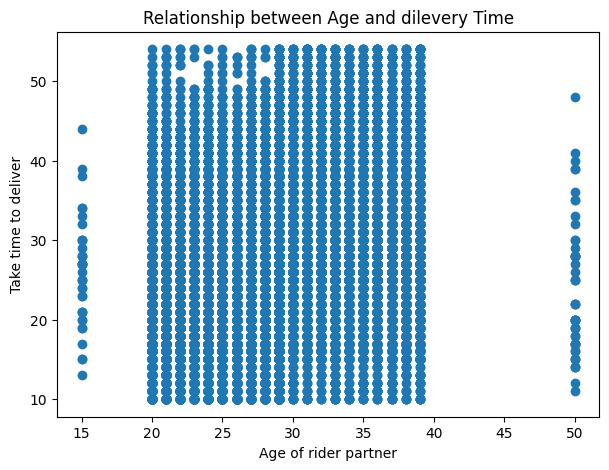

In [13]:
plt.figure(figsize=(7,5))
x=data['Delivery_person_Age']
y=data['Time_taken(min)']
plt.scatter(x,y)
plt.xlabel('Age of rider partner')
plt.ylabel('Take time to deliver')
plt.title('Relationship between Age and dilevery Time')
plt.show()

### Delivery Partner Age vs Delivery Time

**Explanation:**

This scatter plot illustrates the relationship between **delivery partner age** and **delivery time**.

From the visualization, delivery times are spread across all age groups without showing a strong linear trend. The majority of delivery times fall within the **15–40 minute range**, regardless of the age of the delivery partner.

This observation indicates that **age alone is not a strong predictor of delivery performance**, and other factors—such as distance, traffic conditions, or driver ratings—likely have a more significant impact on delivery time.

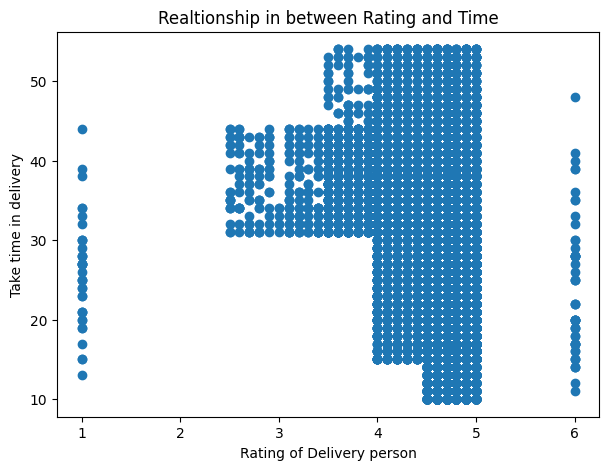

In [14]:
x=data['Delivery_person_Ratings']
y=data['Time_taken(min)']
plt.figure(figsize=(7,5))
plt.scatter(x,y)
plt.xlabel('Rating of Delivery person')
plt.ylabel('Take time in delivery')
plt.title('Realtionship in between Rating and Time')
plt.show()

### Delivery Partner Ratings vs Delivery Time

**Explanation:**

This visualization examines the relationship between **delivery partner ratings** and **delivery time**.

The scatter plot indicates that **higher-rated delivery partners (ratings between 4.5 and 5.0)** tend to deliver orders **slightly faster and with greater consistency**. In contrast, **lower-rated partners exhibit higher variability** in delivery times, suggesting less predictable performance.

These insights imply that **delivery ratings are a meaningful indicator of delivery efficiency**, and prioritizing higher-rated partners may help improve overall delivery time reliability.

In [15]:
data['Delivery_person_Age'].describe()

,Delivery_person_Age
count,45593.000000
mean,29.544075
std,5.696793
min,15.000000
25%,25.000000
50%,29.000000
75%,34.000000
max,50.000000


In [16]:
data[data['Delivery_person_Age']<18].shape

(38, 11)

In [17]:
data[data['Delivery_person_Age']>=18].shape

(45555, 11)

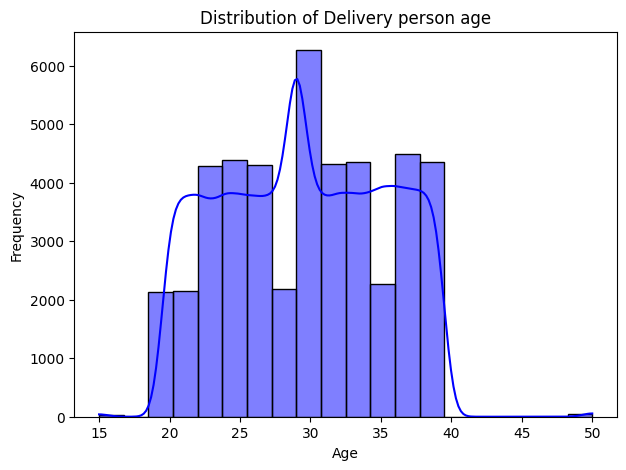

In [18]:
plt.figure(figsize=(7,5))
sns.histplot(data['Delivery_person_Age'],kde=True,bins=20,color='blue')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery person age')
plt.show()

### Distribution of Delivery Partner Age

**Explanation:**

The histogram with an overlaid **Kernel Density Estimation (KDE) curve** illustrates the distribution of **delivery partner ages**.

The age distribution appears **approximately normal (bell-shaped)**, with the majority of delivery partners concentrated in the **25–35 year age range**. A **slight right skew** is observed, indicating fewer delivery partners in the higher age brackets, particularly **above 45 years**.

This distribution suggests that the delivery workforce is predominantly composed of young to mid-aged individuals, which may influence overall delivery efficiency and operational dynamics.

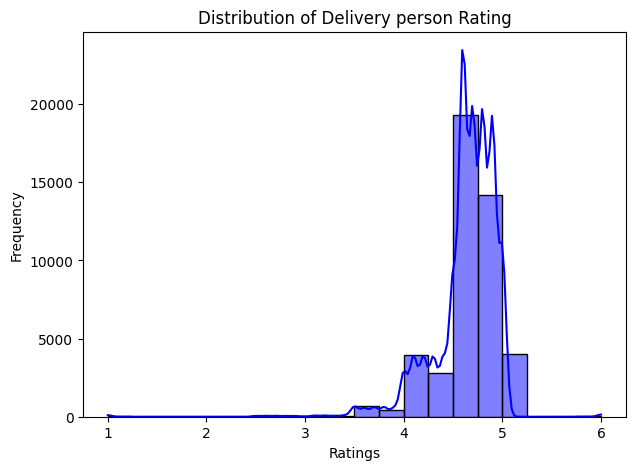

In [19]:
plt.figure(figsize=(7,5))
sns.histplot(data['Delivery_person_Ratings'],kde=True,bins=20,color='blue')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery person Rating')
plt.show()

### Distribution of Delivery Partner Ratings

**Explanation:**

This plot shows the distribution of **delivery partner ratings** across the dataset.

Most delivery partners have ratings in the **4.5–5.0 range**, indicating **generally strong performance levels**. The distribution is **left-skewed**, which implies that delivery partners with **very low ratings (below 3.5)** are relatively rare.

This skewness suggests effective performance screening or rating mechanisms within the delivery system, and it also highlights why ratings serve as a valuable feature for predicting delivery efficiency.

In [20]:
data[data['Delivery_person_Ratings']>=2.5].shape

(45555, 11)

In [21]:
def classify_ratings_group(rating):
    if 2.5<= rating <4:
        return 0.0
    elif 4<= rating < 4.5:
        return 1.0
    elif 4.5<= rating <5:
        return 2.0
    else:
        return 3.0

data['rating_group']=data['Delivery_person_Ratings'].apply(classify_ratings_group)

In [22]:
data.groupby(by='rating_group')['Time_taken(min)'].mean()

,Time_taken(min)
rating_group,
0.0,37.142965
1.0,34.647946
2.0,24.288842
3.0,25.515048


In [23]:
def classify_ratings_group(rating):
    if 2.5<= rating <4:
        return 0.0
    elif 4<= rating < 4.5:
        return 1.0
    elif 4.5<= rating <5:
        return 2.0
    else:
        return 3.0

data['Age_group']=data['Delivery_person_Age'].apply(classify_ratings_group)

In [24]:
data.groupby(by='Age_group')['Time_taken(min)'].mean()

,Time_taken(min)
Age_group,
3.0,26.294607


In [25]:
data.groupby(by='rating_group')['Time_taken(min)'].mean()

,Time_taken(min)
rating_group,
0.0,37.142965
1.0,34.647946
2.0,24.288842
3.0,25.515048


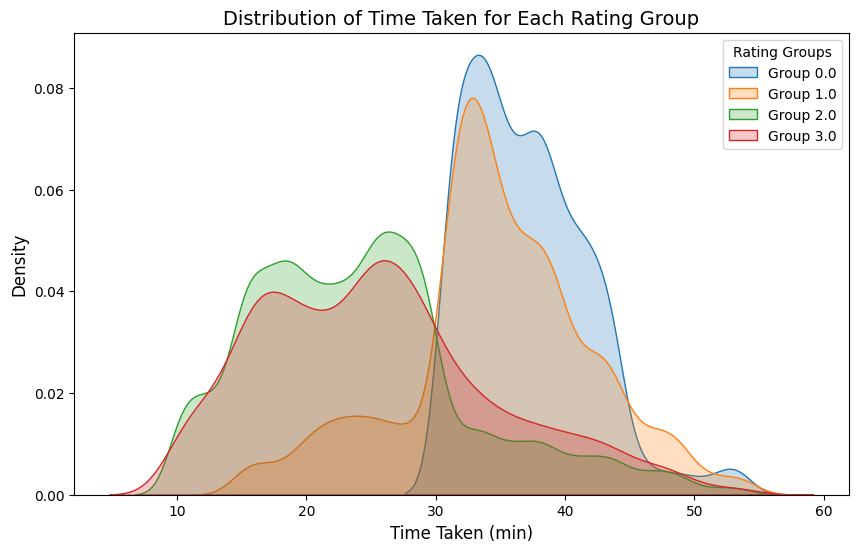

In [26]:
rating_groups = data.groupby('rating_group')['Time_taken(min)']

plt.figure(figsize=(10, 6))
for group, values in rating_groups:
    sns.kdeplot(values, label=f'Group {group}', fill=True)

plt.title('Distribution of Time Taken for Each Rating Group', fontsize=14)
plt.xlabel('Time Taken (min)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Rating Groups')
plt.show()

### Delivery Time Distribution Across Rating Groups

**Explanation:**

This **Kernel Density Estimation (KDE) plot** compares the distribution of **delivery times** across different **delivery partner rating groups**.

The **highest-rated group (Group 3)** exhibits the most **concentrated distribution**, with a clear peak around **24–25 minutes**, indicating faster and more consistent deliveries. In contrast, **lower-rated groups (Groups 0–1)** display wider distributions and higher average delivery times.

These patterns confirm that **higher-rated delivery partners tend to be more efficient and reliable**, reinforcing the importance of delivery ratings as a key predictive feature in delivery time estimation models.

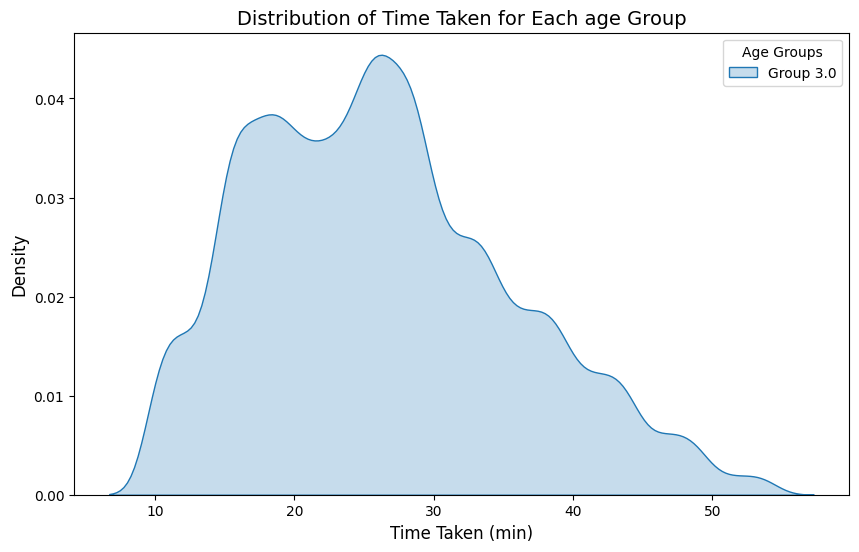

In [27]:
age_groups = data.groupby('Age_group')['Time_taken(min)']

plt.figure(figsize=(10, 6))
for group, values in age_groups:
    sns.kdeplot(values, label=f'Group {group}', fill=True)

plt.title('Distribution of Time Taken for Each age Group', fontsize=14)
plt.xlabel('Time Taken (min)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Age Groups')
plt.show()

### Delivery Time Distribution Across Age Groups

**Explanation:**

This plot compares the **distribution of delivery times** across different **delivery partner age groups**.

The distributions across all age groups appear **remarkably similar**, with no group showing a distinct advantage in terms of faster or more consistent delivery times. This suggests that **age is not a significant factor** in determining delivery speed.

These findings are consistent with the earlier **age vs. delivery time scatter plot**, reinforcing the conclusion that other features—such as distance, traffic conditions, or delivery partner ratings—play a more influential role in predicting delivery performance.

/tmp/ipython-input-1399451457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


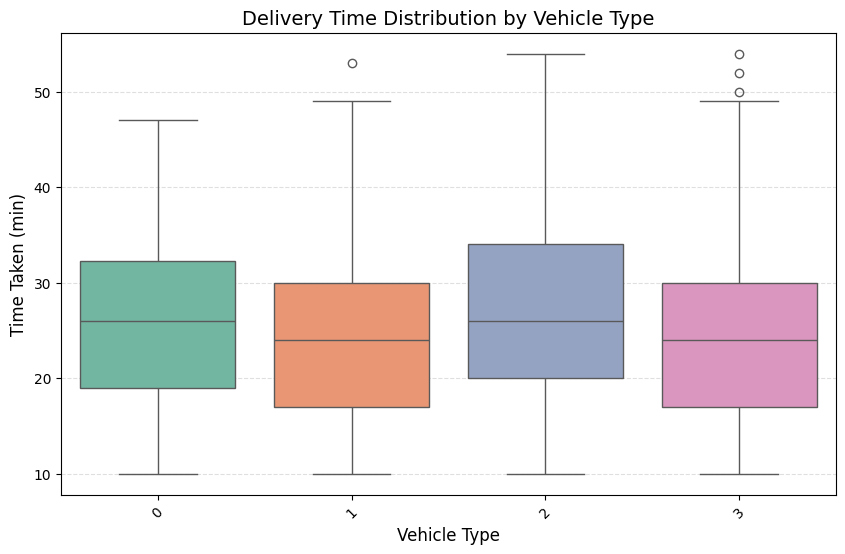

In [32]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Type_of_vehicle',
    y='Time_taken(min)',
    data=data,
    palette='Set2'   # soft, professional colors
)

plt.title('Delivery Time Distribution by Vehicle Type', fontsize=14)
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Time Taken (min)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

### Vehicle Type vs Delivery Time

**Explanation:**

This analysis uses **box plots** to visualize the **distribution of delivery times** across different **vehicle types**.

Each box plot represents the **median delivery time** (center line), **interquartile range (IQR)** (box), and **outliers** (individual points). This visualization enables a clear comparison of delivery performance across vehicle categories.

**Key Insights:**
- Compare **median delivery times** among different vehicle types  
- Identify vehicle types with **more consistent delivery times** (smaller IQR)  
- Detect vehicle types with **frequent outliers**, indicating unusually long or short deliveries  
- Assess whether **vehicle type** should be considered an important feature in the delivery time prediction model

/tmp/ipython-input-3182011860.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


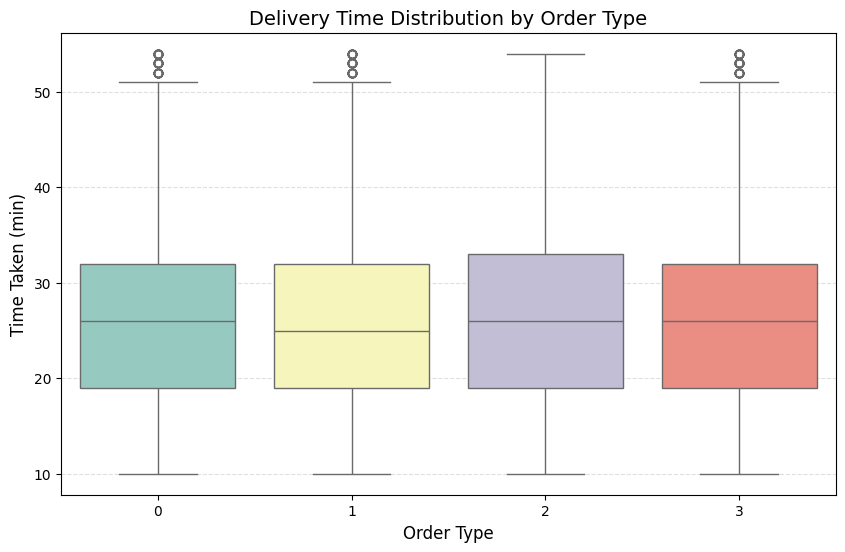

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Type_of_order',
    y='Time_taken(min)',
    data=data,
    palette='Set3'   # soft and distinct colors
)

plt.title('Delivery Time Distribution by Order Type', fontsize=14)
plt.xlabel('Order Type', fontsize=12)
plt.ylabel('Time Taken (min)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

### Order Type vs Delivery Time

**Explanation:**

This analysis uses **box plots** to compare the **distribution of delivery times** across different **order types** such as *Snack, Drinks, Buffet,* and *Meal*.

The visualization highlights differences in **median delivery time**, **variability**, and the presence of **outliers** for each order category, providing insights into how order characteristics affect delivery duration.

**Key Insights:**
- Certain order types may require **longer preparation times**, leading to increased delivery duration  
- Some order categories exhibit **greater variability** in delivery times  
- Helps determine whether **order type** significantly influences delivery performance  
- Valuable for **feature selection** and understanding **operational bottlenecks**

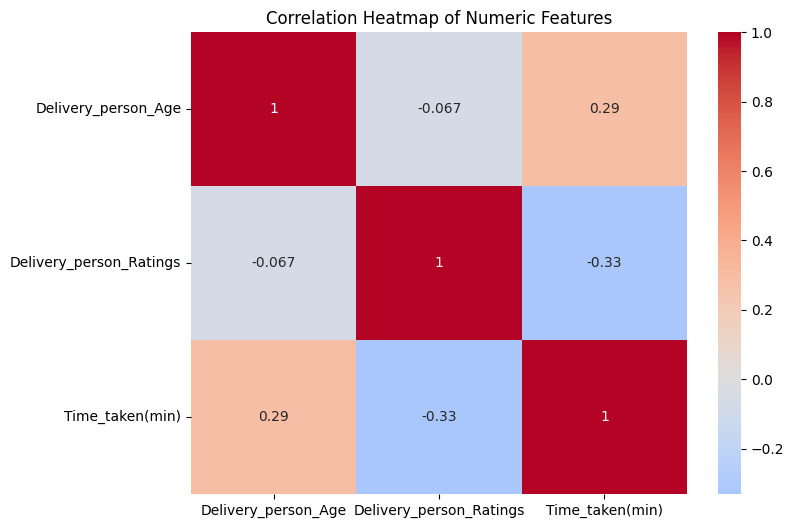

In [30]:
# Select numeric columns for correlation
numeric_cols = data[['Delivery_person_Age', 'Delivery_person_Ratings', 'Time_taken(min)']]
correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

### Correlation Analysis

**Explanation:**

This analysis presents a **correlation heatmap** illustrating the relationships between **numeric variables** in the dataset.  
Correlation values range from **-1** (strong negative correlation) to **+1** (strong positive correlation), with values close to **0** indicating weak or no linear relationship.

**Key Insights:**
- **Age vs Delivery Time:** Shows a **weak correlation**, indicating age has limited influence on delivery duration  
- **Ratings vs Delivery Time:** Exhibits a **moderate negative correlation**, suggesting that higher-rated delivery partners tend to complete deliveries faster  
- **Age vs Ratings:** Displays **minimal correlation**, implying these features are largely independent  


/tmp/ipython-input-2888119595.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


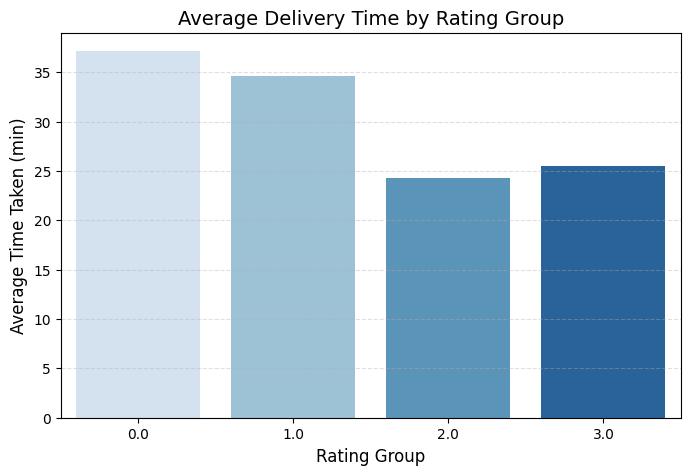

In [34]:
avg_time_by_rating = data.groupby('rating_group')['Time_taken(min)'].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x='rating_group',
    y='Time_taken(min)',
    data=avg_time_by_rating,
    palette='Blues'   # intuitive: darker = higher efficiency
)

plt.title('Average Delivery Time by Rating Group', fontsize=14)
plt.xlabel('Rating Group', fontsize=12)
plt.ylabel('Average Time Taken (min)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

### Rating Group Analysis

**Explanation:**

This analysis uses a **bar chart** to compare the **average delivery time** across different **delivery partner rating groups**.

The visualization highlights a clear trend where **higher-rated delivery partners consistently achieve faster delivery times**. By aggregating delivery times within each rating category, this plot provides a quantitative comparison of performance differences.

**Key Insights:**
- **Clear inverse relationship:** Higher ratings correspond to faster deliveries  
- **Performance gap visibility:** Makes delivery efficiency differences between rating groups explicit  
- **Model validation:** Confirms that delivery partner ratings are a strong and reliable predictor  

**Average Delivery Time by Rating Group:**